t=0, rho=0.3000, new_infs=184, recov=106
t=10, rho=0.7435, new_infs=309, recov=297
t=20, rho=0.7560, new_infs=305, recov=316
t=30, rho=0.7665, new_infs=279, recov=287
t=40, rho=0.7650, new_infs=296, recov=293
t=50, rho=0.7635, new_infs=300, recov=340
t=60, rho=0.7545, new_infs=289, recov=305
t=70, rho=0.7405, new_infs=298, recov=291
t=80, rho=0.7625, new_infs=302, recov=318
t=90, rho=0.7715, new_infs=267, recov=291


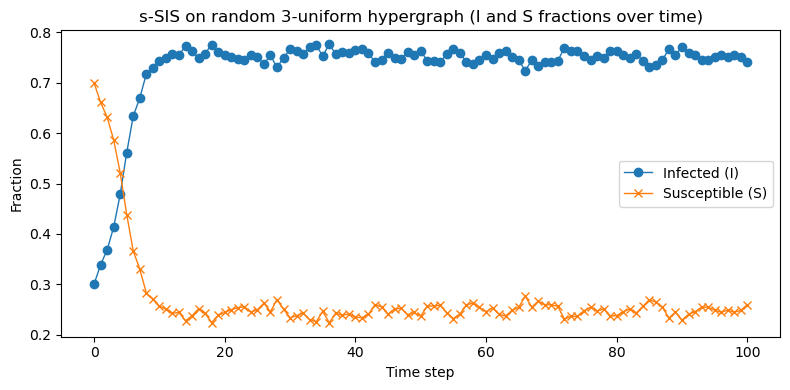

In [7]:
# s-SIS on a random 3-uniform hypergraph (no Theta, no Phi) - stochastic synchronous simulator
# - Generates H(n,m,3) with target mean hyperdegree kappa
# - Runs discrete-time synchronous s-SIS:
#     * For each hyperedge e={i,j,k}, if exactly d-1 (=2) nodes in e are infected at time t,
#       then the remaining susceptible node becomes infected at t+1 with probability beta.
#     * Each infected node recovers at t+1 with probability mu.
# - Plots fractions of Infected (I) and Susceptible (S) over time in one figure.
#
# Use: copy into a .py or Jupyter cell and run. Adjust parameters below as needed.

import numpy as np
import random
import math
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

def generate_hypergraph_H_n_m_3(n, kappa, seed, batch_size, verbose=False):
    """
    Generate a random 3-uniform hypergraph H(n, m, 3) without duplicate hyperedges.
    Returns a numpy array of shape (m,3) with each row a sorted triple of node indices.
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("Requested m exceeds C(n,3). Reduce kappa or increase n.")

    nodes = np.arange(n)
    edges_set = set()
    attempts = 0
    # sample candidate triples in batches to reduce python overhead
    while len(edges_set) < m:

        tris = np.random.choice(nodes, size=(batch_size, d), replace=True) # 因为要抽取batch_size*d个不同元素，所以True

        # ensure each triple has distinct nodes; resample rows that contain duplicates
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                # resample without replacement for this row
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        # add unique triples into the set

        # add unique triples into the set 添加唯一超边到集合
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
        attempts += tris.shape[0]

        if verbose and (attempts % (batch_size * 50) == 0):
            print(f"Progress: collected {len(edges_set)}/{m} edges after ~{attempts} attempts")

    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)  # ensure canonical ordering i<j<k for each row 最终确保排序
    return hyperedges #hyperedges:[[0 1 2] [1 3 4]]


def run_stochastic_sSIS(hyperedges, n, beta, mu, T, init_frac, seed=None, verbose=False):
    """
    Run synchronous stochastic s-SIS (no Theta) on the given hyperedges.
    Returns:
      - rho_ts: array of infected fraction at each time step (length T+1)
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # initialize node states (0 = S, 1 = I)
    states = np.zeros(n, dtype=int)
    initial_infected = max(1, int(round(init_frac * n)))
    init_nodes = np.random.choice(n, size=initial_infected, replace=False)
    states[init_nodes] = 1

    rho_ts = []
    for t in range(T):
        rho = states.sum() / n
        rho_ts.append(rho)

        # 获取每个超边中节点的状态states_per_edge+数量inf_counts
        states_per_edge = states[hyperedges]  # shape (m,3) [[0 1 2] [1 2 3]] 0和1和3是感染节点 [1 1 0 1]
        inf_counts = states_per_edge.sum(axis=1) # [2 2]

        # hyperedges that can cause infection: exactly d-1 infected (==2)
        candidates = np.where(inf_counts == 2)[0] # 提取索引数组 [0 1]
        new_infections = set() # 创建空集合
        for idx in candidates: 
            nodes = hyperedges[idx] # 提取超边的节点 nodes [0 1 2] / [1 2 3]
            node_states = states[nodes] # 提取节点的状态 node_states [1 1 0] / [0 1 1]
            sus_pos = np.where(node_states == 0)[0] # [2]第三个节点为0易感  /  [0]第一个节点为0易感
            if sus_pos.size == 0:  # 全是感染节点则条件成立 跳过这个超边（没啥用的检查）
                continue 

            sus_node = nodes[sus_pos[0]] # 该节点“2”加入易感 sus_pos[0] = 2 / sus_node = nodes[sus_pos[0]] = 2
            if np.random.rand() < beta:
                new_infections.add(sus_node) # 加入新感染集合[2]

        # recoveries: each infected node recovers with probability mu
        infected_nodes = np.where(states == 1)[0] # [0 1 3]
        if infected_nodes.size > 0:
            recover_flags = np.random.rand(infected_nodes.size) < mu  # 比如 [0.15, 0.82, 0.25]-->比如 [True, False, True]
            recovered_nodes = infected_nodes[recover_flags] # 比如 [0, 3]
        else:
            recovered_nodes = np.array([], dtype=int)  # 处理没有感染节点的情况

        # synchronous update: recoveries first, then infections
        states_next = states.copy()
        if recovered_nodes.size > 0:
            states_next[recovered_nodes] = 0
        for node in new_infections:
            if states_next[node] == 0:
                states_next[node] = 1

        states = states_next

        if verbose and (t % 10 == 0):
            print(f"t={t}, rho={rho:.4f}, new_infs={len(new_infections)}, recov={recovered_nodes.size}")

    # append final state's infected fraction
    rho_ts.append(states.sum() / n)
    return np.array(rho_ts)


# -------------------- Parameters (example) --------------------
n = 2000
kappa = 6.0
beta = 0.3
mu = 0.2
T = 100
init_frac = 0.3
seed = 12345

# generate hypergraph and run dynamics
hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=1000)
rho_ts = run_stochastic_sSIS(hyperedges, n=n, beta=beta, mu=mu, T=T, init_frac=init_frac, seed=seed, verbose=True)

# plot infected & susceptible fractions over time (one figure)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
ts = np.arange(len(rho_ts))
plt.plot(ts, rho_ts, marker='o', linewidth=1)
plt.plot(ts, 1.0 - rho_ts, marker='x', linewidth=1)
plt.xlabel("Time step")
plt.ylabel("Fraction")
plt.title("s-SIS on random 3-uniform hypergraph (I and S fractions over time)")
plt.legend(["Infected (I)", "Susceptible (S)"])
plt.tight_layout()
plt.show()
